# 01 — Análisis Exploratorio y Epidemiológico (BRFSS 2015)

**Fase 1A.** Dataset *CDC Diabetes Health Indicators* (BRFSS 2015), 253,680 encuestados, 21 indicadores de salud, prevalencia poblacional **real ~13.9%**. El objetivo de esta fase es entender la estructura de los datos y la epidemiología de la diabetes antes de modelar.

In [1]:
# --- Setup: rutas y utilidades de presentación ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

BR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(BR / "src"))
sys.path.insert(0, str(BR.parent / "src"))
from predia_brfss import config, codebook

RES = BR / "results"
def show(p, w=None):
    display(Image(filename=str(p), width=w))
def table(csv, **kw):
    return pd.read_csv(csv, **kw)
def load(j):
    return json.load(open(j))
pd.set_option("display.max_columns", 40)
print("Entorno listo:", BR)


Entorno listo: /home/wowo/Descargas/predia/ml-research/brfss


## Distribución de clases
Desbalance real (13.9% positivos) — clave: NO re-balancear el dataset primario, porque la prevalencia real es necesaria para que las probabilidades y los OR/RR posteriores sean clínicamente interpretables. El dataset *012* muestra el gradiente natural No-DM → Prediabetes → DM.

Filas: 253680 | Duplicados: 24206 (9.542%) | Nulos: 0
Balance (%): {'0': 86.067, '1': 13.933}


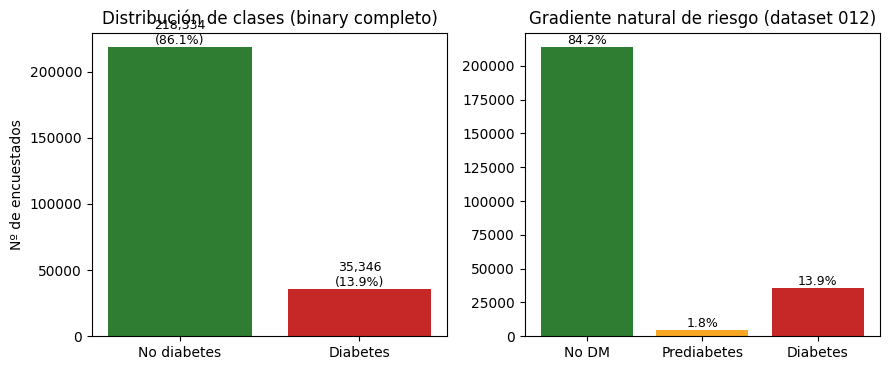

In [2]:
a = load(RES/'eda'/'audit_binary.json')
print('Filas:', a['shape']['rows'], '| Duplicados:', a['n_duplicated_rows'],
      f"({a['pct_duplicated_rows']}%)", '| Nulos:', a['total_nulls'])
print('Balance (%):', a['target']['balance_pct'])
show(RES/'eda'/'class_distribution.png')

**Duplicados (~9.5%):** esperable en BRFSS — son encuestados distintos con idénticas respuestas categóricas, no errores; se conservan (eliminarlos sesgaría la prevalencia).

## Correlaciones con el objetivo
Señal preliminar (rojo = riesgo, azul = protector).

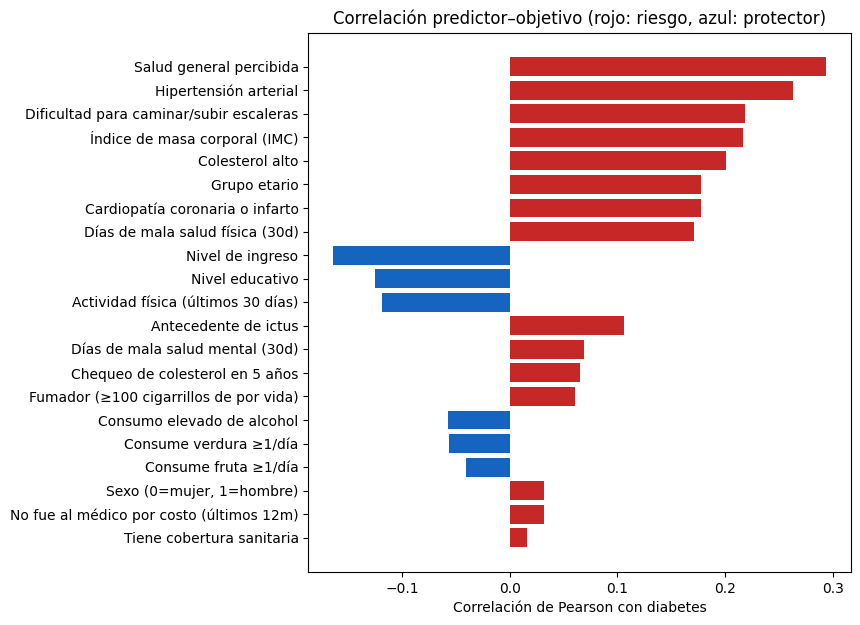

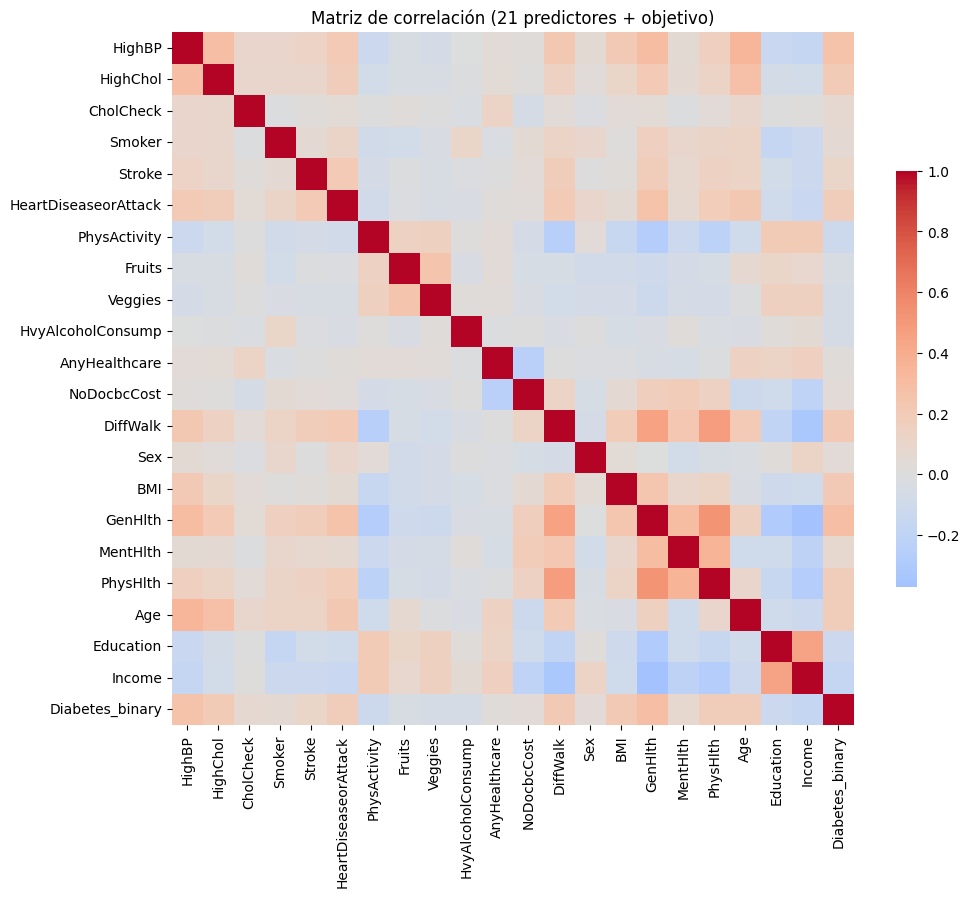

In [3]:
show(RES/'eda'/'correlation_with_target.png')
show(RES/'eda'/'correlation_heatmap.png')

## Gradientes de prevalencia por variables ordinales
La prevalencia crece monótonamente con la edad, peor salud percibida, mayor IMC y menor ingreso/educación — coherente con la epidemiología de la DM2.

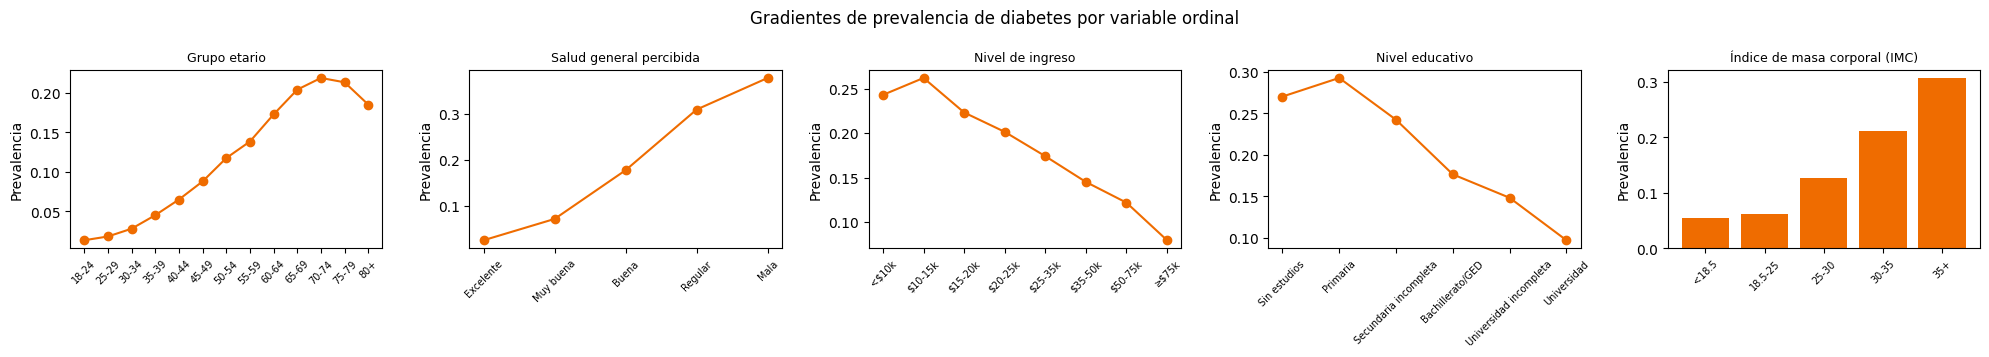

In [4]:
show(RES/'eda'/'prevalence_gradients.png')

## Análisis epidemiológico (Odds Ratio / Riesgo Relativo)
Asociación de cada factor binario con la diabetes, agrupada por dominio (cardiometabólico, conductual, funcional, socioeconómico).

In [5]:
table(RES/'eda'/'epidemiology_associations.csv')

,domain,variable,label,prev_exposed,prev_unexposed,or_or,or_ci95,rr_rr,rr_ci95
0,Cardiometabólico / cardiovascular,CholCheck,Chequeo de colesterol en 5 años,0.1437,0.0254,6.429,"[5.654, 7.31]",5.649,"[4.985, 6.401]"
1,Cardiometabólico / cardiovascular,HighBP,Hipertensión arterial,0.2445,0.0604,5.038,"[4.91, 5.169]",4.051,"[3.959, 4.144]"
2,Estado de salud / funcionalidad,DiffWalk,Dificultad para caminar/subir escaleras,0.3075,0.1053,3.771,"[3.679, 3.866]",2.919,"[2.864, 2.975]"
3,Cardiometabólico / cardiovascular,HeartDiseaseorAttack,Cardiopatía coronaria o infarto,0.3297,0.1195,3.623,"[3.517, 3.733]",2.758,"[2.7, 2.817]"
4,Cardiometabólico / cardiovascular,HighChol,Colesterol alto,0.2201,0.0798,3.255,"[3.178, 3.333]",2.758,"[2.702, 2.816]"
5,Cardiometabólico / cardiovascular,Stroke,Antecedente de ictus,0.3175,0.1318,3.065,"[2.935, 3.2]",2.409,"[2.338, 2.483]"
6,Conductual / estilo de vida,Smoker,Fumador (≥100 cigarrillos de por vida),0.1629,0.1206,1.420,"[1.388, 1.452]",1.352,"[1.326, 1.378]"
7,Socioeconómico / acceso,NoDocbcCost,No fue al médico por costo (últimos 12m),0.1752,0.1360,1.349,"[1.3, 1.401]",1.288,"[1.249, 1.329]"
8,Socioeconómico / acceso,AnyHealthcare,Tiene cobertura sanitaria,0.1406,0.1145,1.265,"[1.196, 1.339]",1.228,"[1.168, 1.291]"
9,Demográfico,Sex,"Sexo (0=mujer, 1=hombre)",0.1516,0.1297,1.199,"[1.173, 1.227]",1.169,"[1.147, 1.192]"


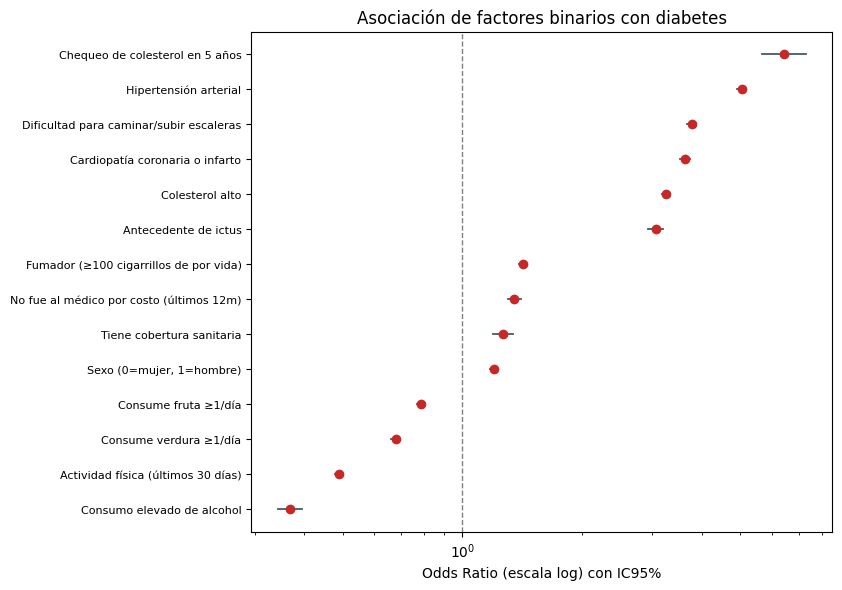

In [6]:
show(RES/'eda'/'epidemiology_forest.png')

## Importancia preliminar y outliers

,feature,label,rf_importance,mutual_info
0,BMI,Índice de masa corporal (IMC),0.15348,0.02611
1,GenHlth,Salud general percibida,0.13912,0.04665
2,Age,Grupo etario,0.11281,0.02323
3,HighBP,Hipertensión arterial,0.10926,0.04172
4,Income,Nivel de ingreso,0.07037,0.01845
5,PhysHlth,Días de mala salud física (30d),0.05900,0.01077
6,HighChol,Colesterol alto,0.05831,0.02590
7,MentHlth,Días de mala salud mental (30d),0.04704,0.00161
8,Education,Nivel educativo,0.04665,0.00804
9,DiffWalk,Dificultad para caminar/subir escaleras,0.03090,0.01942


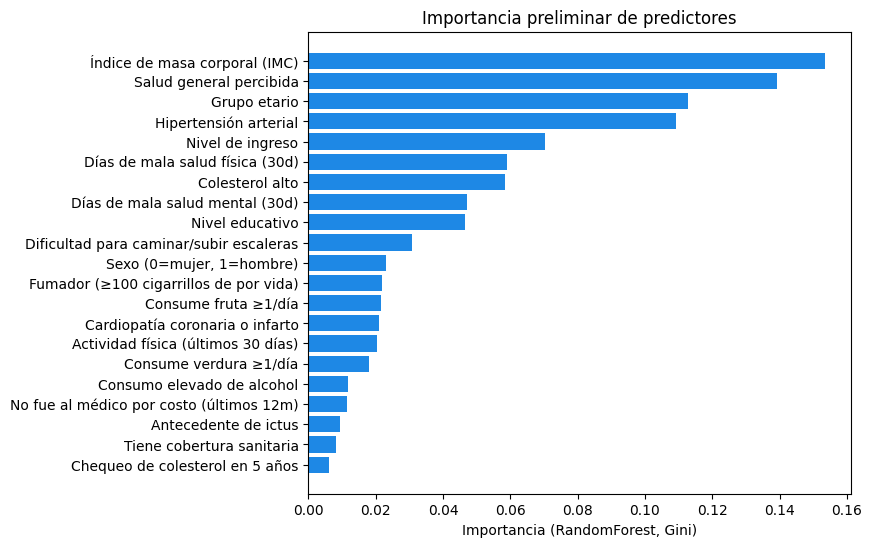

In [7]:
display(table(RES/'eda'/'preliminary_importance.csv'))
show(RES/'eda'/'preliminary_importance.png')

In [8]:
table(RES/'eda'/'outliers_summary.csv', index_col=0)

,q1,q3,iqr,lower_fence,upper_fence,n_outliers,pct_outliers,min,max,mean,std
BMI,24.0,31.0,7.0,13.5,41.5,9847.0,3.882,12.0,98.0,28.382364,6.608694
GenHlth,2.0,3.0,1.0,0.5,4.5,12081.0,4.762,1.0,5.0,2.511392,1.068477
MentHlth,0.0,2.0,2.0,-3.0,5.0,36208.0,14.273,0.0,30.0,3.184772,7.412847
PhysHlth,0.0,3.0,3.0,-4.5,7.5,40949.0,16.142,0.0,30.0,4.242081,8.717951
Age,6.0,10.0,4.0,0.0,16.0,0.0,0.000,1.0,13.0,8.032119,3.054220
Education,4.0,6.0,2.0,1.0,9.0,0.0,0.000,1.0,6.0,5.050434,0.985774
Income,5.0,8.0,3.0,0.5,12.5,0.0,0.000,1.0,8.0,6.053875,2.071148


### Conclusiones Fase 1A
- Factores **cardiovasculares/metabólicos** (hipertensión, colesterol, IMC, cardiopatía) y **funcionales** (salud general percibida, dificultad para caminar) son los más asociados.
- Existe un **gradiente socioeconómico** (ingreso/educación) y de **edad**.
- Variables **conductuales** (actividad física, dieta) muestran efecto protector.
- El desbalance y la prevalencia real motivan el enfoque de **probabilidad calibrada + estratificación**, no un simple clasificador 0/1.